### Reference:
Devabrat, M., 2022. Predictive Maintenance on Ship's Main Engine using AI. Available at: https://dx.doi.org/10.21227/g3za-v415. [Accessed 5 March 2024]

# Project 5.3.1

## Initial Data Evaluation

### Import of Libraries and Dataset 

In [21]:
# Import all neccesary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

# URL to import data set from GitHub.
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'

# Put data into pd df
ship_data = pd.read_csv(url)

### Exploratory Data Analysis

In [22]:
# Examining shape of dataset
print(ship_data.shape)
ship_data.head()
# Examining data types and missing values
print(ship_data.dtypes)
print(ship_data.isnull().sum())
# Checking for duplicate values
print(f"\nNumber of duplicate rows: {ship_data.duplicated().sum()}")
print(f"Percentage of duplicate rows: {(ship_data.duplicated().sum() / len(ship_data)) * 100:.2f}%")



(19535, 6)
Engine rpm            int64
Lub oil pressure    float64
Fuel pressure       float64
Coolant pressure    float64
lub oil temp        float64
Coolant temp        float64
dtype: object
Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
dtype: int64

Number of duplicate rows: 0
Percentage of duplicate rows: 0.00%


All either integers or floating point numbers, with no null values. Makes data cleaning easier...

In [23]:
# Summary statistics in icnluding mean and median
print("Mean for each feature:")
print(ship_data.mean())
print("\nMedian for each feature:")
print(ship_data.median())
print("\nFull descriptive statistics:")
print(ship_data.describe())

Mean for each feature:
Engine rpm          791.239263
Lub oil pressure      3.303775
Fuel pressure         6.655615
Coolant pressure      2.335369
lub oil temp         77.643420
Coolant temp         78.427433
dtype: float64

Median for each feature:
Engine rpm          746.000000
Lub oil pressure      3.162035
Fuel pressure         6.201720
Coolant pressure      2.166883
lub oil temp         76.817350
Coolant temp         78.346662
dtype: float64

Full descriptive statistics:
         Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
count  19535.000000      19535.000000   19535.000000      19535.000000   
mean     791.239263          3.303775       6.655615          2.335369   
std      267.611193          1.021643       2.761021          1.036382   
min       61.000000          0.003384       0.003187          0.002483   
25%      593.000000          2.518815       4.916886          1.600466   
50%      746.000000          3.162035       6.201720          2.166883   
7

### Visualisation

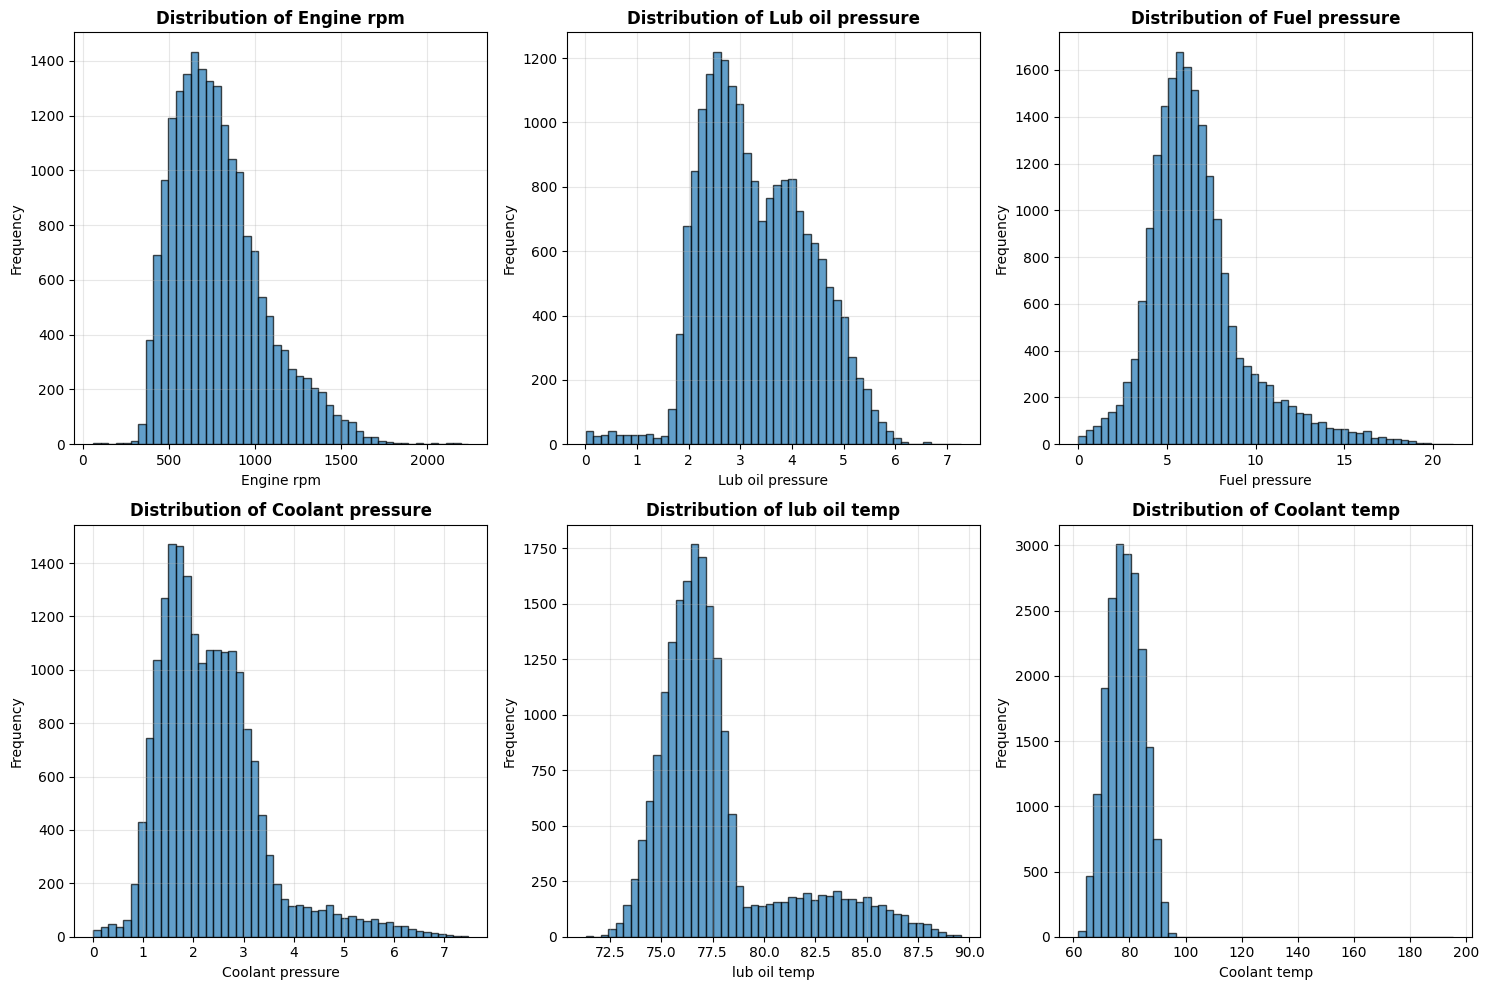

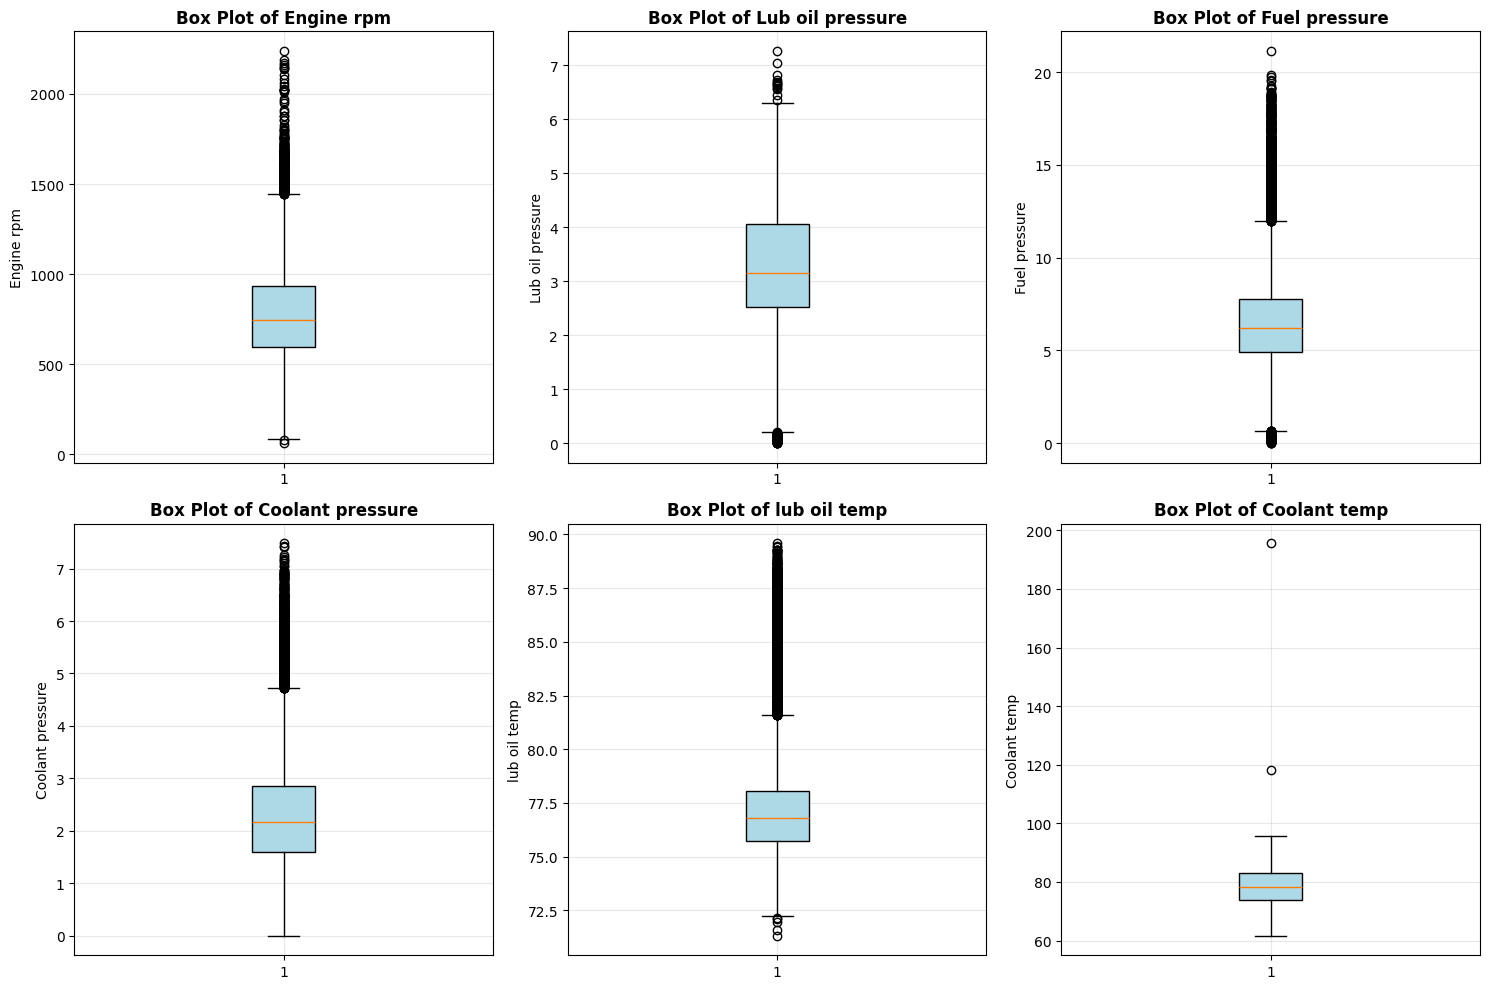

In [24]:
# Visualise data to determine distribution and extreme values using distribution plots and box plots

# Distribution plots (histograms) for all features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(ship_data.columns):
    axes[i].hist(ship_data[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plots for all features to identify outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(ship_data.columns):
    box_plot = axes[i].boxplot(ship_data[col], patch_artist=True)
    box_plot['boxes'][0].set_facecolor('lightblue')
    axes[i].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

For all histograms can see a moderate but skewed bell shaped curve, with skewing to the left on most. Box plots often show a large amount of outliers, especialy on Engine rpm, Fuel pressure, Coolant pressure and lub oil temp. 

## Anomaly Detection

### IQR for each feature

In [25]:
# IQR method to identify outliers for each feature

# Calculate Q1, Q3, and IQR for each feature
Q1 = ship_data.quantile(0.25)
Q3 = ship_data.quantile(0.75)
IQR = Q3 - Q1

# Display IQR statistics
print("IQR Statistics for each feature:")
print(f"Q1 (25th percentile):\n{Q1}\n")
print(f"Q3 (75th percentile):\n{Q3}\n")
print(f"IQR (Q3 - Q1):\n{IQR}\n")

# Calculate lower and upper bounds for each feature
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bounds (Q1 - 1.5*IQR):")
print(lower_bound)
print("\nUpper bounds (Q3 + 1.5*IQR):")
print(upper_bound)

IQR Statistics for each feature:
Q1 (25th percentile):
Engine rpm          593.000000
Lub oil pressure      2.518815
Fuel pressure         4.916886
Coolant pressure      1.600466
lub oil temp         75.725990
Coolant temp         73.895421
Name: 0.25, dtype: float64

Q3 (75th percentile):
Engine rpm          934.000000
Lub oil pressure      4.055272
Fuel pressure         7.744973
Coolant pressure      2.848840
lub oil temp         78.071691
Coolant temp         82.915411
Name: 0.75, dtype: float64

IQR (Q3 - Q1):
Engine rpm          341.000000
Lub oil pressure      1.536457
Fuel pressure         2.828087
Coolant pressure      1.248374
lub oil temp          2.345700
Coolant temp          9.019990
dtype: float64

Lower bounds (Q1 - 1.5*IQR):
Engine rpm          81.500000
Lub oil pressure     0.214130
Fuel pressure        0.674755
Coolant pressure    -0.272095
lub oil temp        72.207440
Coolant temp        60.365435
dtype: float64

Upper bounds (Q3 + 1.5*IQR):
Engine rpm          1445

#### New Columns for each feature to mark as outlier

In [26]:
# Create binary columns (0 or 1) for each feature indicating if value is an outlier
for col in ship_data.columns:
    # Create column name for outlier indicator
    outlier_col_name = f'{col}_outlier'
    
    # Identify outliers: values below lower bound OR above upper bound
    ship_data[outlier_col_name] = ((ship_data[col] < lower_bound[col]) | 
                                    (ship_data[col] > upper_bound[col])).astype(int)
    
    # Print summary for each feature
    num_outliers = ship_data[outlier_col_name].sum()
    pct_outliers = (num_outliers / len(ship_data)) * 100
    print(f'\n{col}:')
    print(f'  Number of outliers: {num_outliers} ({pct_outliers:.2f}%)')

# Check first few rows to verify the new columns pulled correctly
print("\nFirst 10 rows with outlier columns:")
print(ship_data.head(10))


Engine rpm:
  Number of outliers: 464 (2.38%)

Lub oil pressure:
  Number of outliers: 66 (0.34%)

Fuel pressure:
  Number of outliers: 1135 (5.81%)

Coolant pressure:
  Number of outliers: 785 (4.02%)

lub oil temp:
  Number of outliers: 2617 (13.40%)

Coolant temp:
  Number of outliers: 2 (0.01%)

First 10 rows with outlier columns:
   Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
0         682          2.391656       4.617196          2.848982   
1         605          5.466877       6.424361          5.727520   
2         658          3.434232       3.680896          1.678708   
3         749          2.094656       7.120927          1.639670   
4         676          3.538228       5.956472          3.225336   
5         589          2.933888       6.358464          2.461478   
6         885          2.034509      15.499680          1.522790   
7         576          5.495972      13.114658          1.251058   
8         535          3.159440       8.676361    

#### Finding # of observations that have at least 2 outliers, and the % of the rows this takes up

In [27]:
# Identify observations (rows) that have outliers in at least 2 features

# Get all outlier columns (columns ending with '_outlier')
outlier_cols = [col for col in ship_data.columns if col.endswith('_outlier')]

# Count how many features are outliers for each row
ship_data['num_outlier_features'] = ship_data[outlier_cols].sum(axis=1)

# Create binary column: 1 if at least 2 features are outliers, 0 otherwise
ship_data['is_outlier_2plus'] = (ship_data['num_outlier_features'] >= 2).astype(int)

# Summary statistics
total_rows = len(ship_data)
rows_with_2plus_outliers = ship_data['is_outlier_2plus'].sum()
pct_with_2plus_outliers = (rows_with_2plus_outliers / total_rows) * 100

print(f"Total number of observations: {total_rows}")
print(f"Observations with outliers in at least 2 features: {rows_with_2plus_outliers} ({pct_with_2plus_outliers:.2f}%)")
print(f"\nDistribution of number of outlier features per row:")
print(ship_data['num_outlier_features'].value_counts().sort_index())

# Show some examples of rows with at least 2 outlier features for sense check
print("\n\nSample of observations with at least 2 outlier features:")
outlier_rows = ship_data[ship_data['is_outlier_2plus'] == 1]
print(outlier_rows[list(ship_data.columns[:6]) + ['num_outlier_features']].head(10))

Total number of observations: 19535
Observations with outliers in at least 2 features: 422 (2.16%)

Distribution of number of outlier features per row:
num_outlier_features
0    14899
1     4214
2      411
3       11
Name: count, dtype: int64


Sample of observations with at least 2 outlier features:
     Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
113        1495          3.276230       3.714396          2.495264   
122        1454          2.063374       6.168260          1.260121   
131         830          3.231908      13.479172          2.568096   
144        1762          1.697487       4.327845          2.523372   
148        1494          2.443220       3.548139          1.953403   
157         534          5.922045      18.044686          5.946436   
160        1546          3.903522       6.205256          5.554939   
249        1004          2.745963      16.554492          5.738463   
260        1378          2.099323       5.522725          5.522853  

#### Thoughts and observations

From the output we can gather that outliers in at least 2 features(columns) is the number we should choose if we want our expected outliers to be between 1%-5% of total rows as 2 features leads to a 2.16% outlier rate.

### One Class SVM Anomaly Detection

#### Scaling data

In [28]:
# Selecting only the original 6 features (exclude outlier columns)
feature_cols = ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 
                'Coolant pressure', 'lub oil temp', 'Coolant temp']
X = ship_data[feature_cols].values

# Standardize the features (important for SVM and PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Setting up one class SVM with moderate gamma and nu values

In [29]:
# First one class SVM with nu at 0.05 & gamma at 0.5
ocsvm_1 = OneClassSVM(nu=0.05, kernel='rbf', gamma=0.5)
ocsvm_1.fit(X_scaled)

# Predict anomalies (-1 for outliers, 1 for normal data points)
y_pred_1 = ocsvm_1.predict(X_scaled)
outlier_mask_1= y_pred_1 == -1

# Checking that table has been created correctly
# print(y_pred_1)

#### Check for percentage to see if within 1%-5%

In [30]:
# Calculate percentage of outliers
outlier_percentage_1 = (outlier_mask_1.sum() / len(y_pred_1)) * 100
print(f"Number of outliers detected: {outlier_mask_1.sum()}")
print(f"Percentage of outliers for #1: {outlier_percentage_1:.2f}%")

Number of outliers detected: 1043
Percentage of outliers for #1: 5.34%


#### Try adusting both gamma and nu a couple times to see what fulfils the required %'s

In [31]:
# Second one class SVM with nu at 0.03 & gamma at 0.5
ocsvm_2 = OneClassSVM(nu=0.03, kernel='rbf', gamma=0.5)
ocsvm_2.fit(X_scaled)

# Predict anomalies (-1 for outliers, 1 for normal data points)
y_pred_2 = ocsvm_2.predict(X_scaled)
outlier_mask_2 = y_pred_2 == -1

# Calculate percentage of outliers
outlier_percentage_2 = (outlier_mask_2.sum() / len(y_pred_2)) * 100
print(f"Number of outliers detected: {outlier_mask_2.sum()}")
print(f"Percentage of outliers for #2: {outlier_percentage_2:.2f}%")

Number of outliers detected: 737
Percentage of outliers for #2: 3.77%


In [32]:
# Third one class SVM with nu at 0.05 & gamma at 0.1
ocsvm_3 = OneClassSVM(nu=0.05, kernel='rbf', gamma=0.1)
ocsvm_3.fit(X_scaled)

# Predict anomalies (-1 for outliers, 1 for normal data points)
y_pred_3 = ocsvm_3.predict(X_scaled)
outlier_mask_3 = y_pred_3 == -1

# Calculate percentage of outliers
outlier_percentage_3 = (outlier_mask_3.sum() / len(y_pred_3)) * 100
print(f"Number of outliers detected: {outlier_mask_3.sum()}")
print(f"Percentage of outliers for #3: {outlier_percentage_3:.2f}%")

Number of outliers detected: 978
Percentage of outliers for #3: 5.01%


Just tried changing gamma to see what would happen, even though changing nu in second OCSVM was correct.

#### PCA and visualisation of optimal OCSVM which was #2

PCA Explained Variance:
PC1: 18.99%
PC2: 17.69%
Total: 36.69%


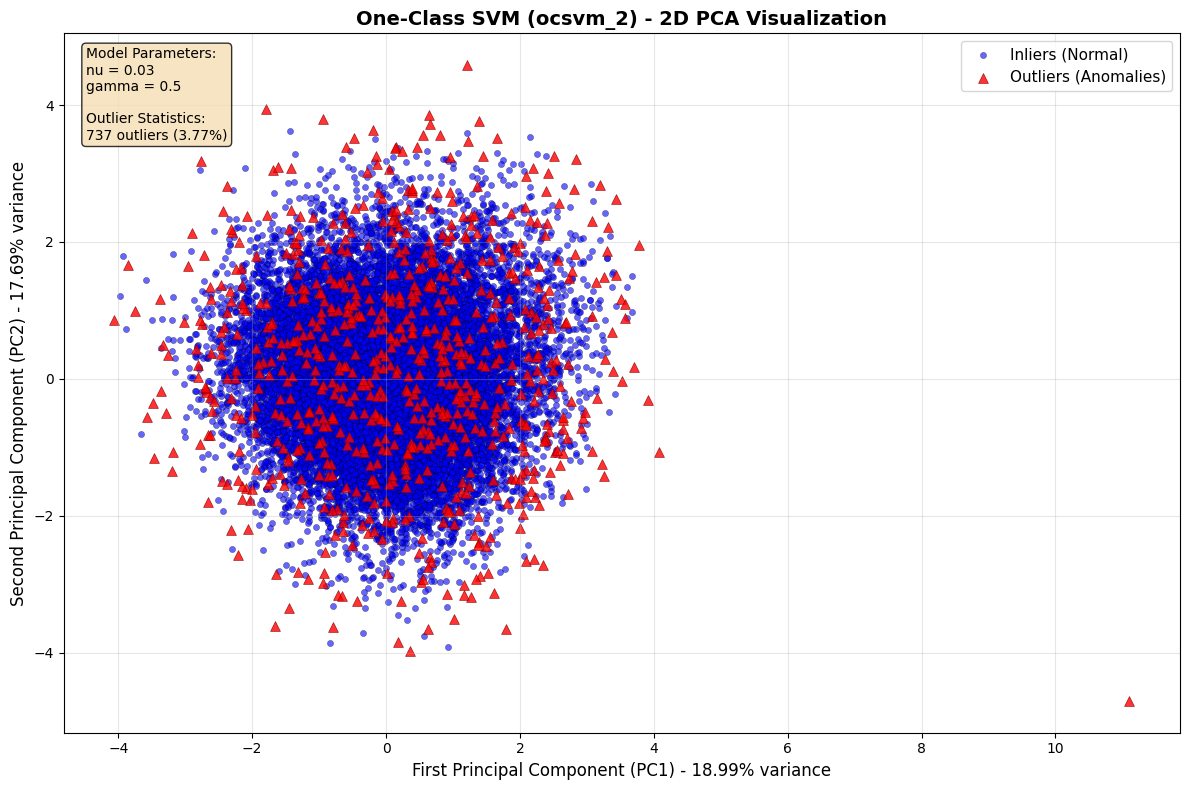

In [33]:
# Perform PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
print(f"PCA Explained Variance:")
print(f"PC1: {explained_variance[0]:.2%}")
print(f"PC2: {explained_variance[1]:.2%}")
print(f"Total: {explained_variance.sum():.2%}")

# Visualization for One-Class SVM (ocsvm_2)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot inliers (normal points)
inlier_mask_2 = ~outlier_mask_2
plt.scatter(X_pca[inlier_mask_2, 0], X_pca[inlier_mask_2, 1], 
            c='blue', alpha=0.6, s=20, label='Inliers (Normal)', 
            edgecolors='black', linewidths=0.3)

# Plot outliers (anomalies) in a different color
plt.scatter(X_pca[outlier_mask_2, 0], X_pca[outlier_mask_2, 1], 
            c='red', alpha=0.8, s=50, label='Outliers (Anomalies)', 
            edgecolors='darkred', linewidths=0.5, marker='^')

# Add labels and title
plt.xlabel(f'First Principal Component (PC1) - {explained_variance[0]:.2%} variance', fontsize=12)
plt.ylabel(f'Second Principal Component (PC2) - {explained_variance[1]:.2%} variance', fontsize=12)
plt.title('One-Class SVM (ocsvm_2) - 2D PCA Visualization', fontsize=14, fontweight='bold')

# Add text box with model parameters and outlier statistics
textstr = f'Model Parameters:\nnu = {ocsvm_2.nu}\ngamma = {ocsvm_2.gamma}\n\nOutlier Statistics:\n{outlier_mask_2.sum()} outliers ({outlier_percentage_2:.2f}%)'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Unfortunately, from this graph we can see that even though our goal of hitting between 1%-5% is hit, where ocsvm_2 outlier % is at 3.77%, the explained variance of PC1 & PC2 are quite low, and the both inliers and outliers are pretty similarly distributed across both axes. This gives us few powerful insights or trends, however we can see that there tend to be more outliers to the outside of the bunching, whereas more inliers within. This is as expected, even if only 'mild'.

### Isolation Forest Anomaly Detection

#### Getting unscaled data

In [34]:
# Use unscaled data (pre-scaling) as this is important for Isolation forest
# Get the original unscaled features
feature_cols = ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 
                'Coolant pressure', 'lub oil temp', 'Coolant temp']
X_unscaled = ship_data[feature_cols].values

# Sense check that getting original unscaled data has worked (original values, not Z-score values)
print("Using unscaled data for Isolation Forest")
print(f"Data shape: {X_unscaled.shape}")
print(f"Feature ranges (min to max):")
for i, col in enumerate(feature_cols):
    print(f"  {col}: {X_unscaled[:, i].min():.2f} to {X_unscaled[:, i].max():.2f}")


Using unscaled data for Isolation Forest
Data shape: (19535, 6)
Feature ranges (min to max):
  Engine rpm: 61.00 to 2239.00
  Lub oil pressure: 0.00 to 7.27
  Fuel pressure: 0.00 to 21.14
  Coolant pressure: 0.00 to 7.48
  lub oil temp: 71.32 to 89.58
  Coolant temp: 61.67 to 195.53


#### Setting up Isolation Forest with different parameter combinations

In [35]:
# Isolation Forest: First attempt with contamination=0.01 (1%), n_estimators=100
iso_forest_1 = IsolationForest(contamination=0.01, n_estimators=100, random_state=42)
iso_forest_1.fit(X_unscaled)

# Predict anomalies (-1 for outliers, 1 for normal data points)
y_pred_if_1 = iso_forest_1.predict(X_unscaled)
outlier_mask_if_1 = y_pred_if_1 == -1

# Calculate percentage of outliers
outlier_percentage_if_1 = (outlier_mask_if_1.sum() / len(y_pred_if_1)) * 100
print(f"Isolation Forest #1:")
print(f"  Parameters: contamination=0.01, n_estimators=100")
print(f"  Number of outliers detected: {outlier_mask_if_1.sum()}")
print(f"  Percentage of outliers: {outlier_percentage_if_1:.2f}%")


Isolation Forest #1:
  Parameters: contamination=0.01, n_estimators=100
  Number of outliers detected: 196
  Percentage of outliers: 1.00%


Testing different contamination values to explore parameter settings and compare results, even though technically no need to try multiple inputs as with OCSVM we can explicityly define % of outliers through contamination value.

In [36]:
# Isolation Forest: Second attempt with contamination=0.0377 (~3.77%), n_estimators=100
iso_forest_2 = IsolationForest(contamination=0.0377, n_estimators=100, random_state=42)
iso_forest_2.fit(X_unscaled)

# Predict anomalies (-1 for outliers, 1 for normal data points)
y_pred_if_2 = iso_forest_2.predict(X_unscaled)
outlier_mask_if_2 = y_pred_if_2 == -1

# Calculate percentage of outliers
outlier_percentage_if_2 = (outlier_mask_if_2.sum() / len(y_pred_if_2)) * 100
print(f"Isolation Forest #2:")
print(f"  Parameters: contamination=0.0377, n_estimators=100")
print(f"  Number of outliers detected: {outlier_mask_if_2.sum()}")
print(f"  Percentage of outliers: {outlier_percentage_if_2:.2f}%")


Isolation Forest #2:
  Parameters: contamination=0.0377, n_estimators=100
  Number of outliers detected: 737
  Percentage of outliers: 3.77%


In [37]:
# Isolation Forest: Third attempt with contamination=0.05 (5%), n_estimators=100
iso_forest_3 = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
iso_forest_3.fit(X_unscaled)

# Predict anomalies (-1 for outliers, 1 for normal data points)
y_pred_if_3 = iso_forest_3.predict(X_unscaled)
outlier_mask_if_3 = y_pred_if_3 == -1

# Calculate percentage of outliers
outlier_percentage_if_3 = (outlier_mask_if_3.sum() / len(y_pred_if_3)) * 100
print(f"Isolation Forest #3:")
print(f"  Parameters: contamination=0.05, n_estimators=100")
print(f"  Number of outliers detected: {outlier_mask_if_3.sum()}")
print(f"  Percentage of outliers: {outlier_percentage_if_3:.2f}%")


Isolation Forest #3:
  Parameters: contamination=0.05, n_estimators=100
  Number of outliers detected: 977
  Percentage of outliers: 5.00%


#### PCA and visualization of Isolation Forest results (using #2 with 3.77% contamination)


In [38]:
# For visualization with PCA, we can scale the data
# Using iso_forest_2 (contamination=0.0377) for visualization

# Scale data for PCA visualization 
scaler_viz = StandardScaler()
X_scaled_viz = scaler_viz.fit_transform(X_unscaled)

# Perform PCA to reduce to 2D for visualization
pca_if = PCA(n_components=2)
X_pca_if = pca_if.fit_transform(X_scaled_viz)

# Calculate explained variance
explained_variance_if = pca_if.explained_variance_ratio_
print(f"PCA Explained Variance (for visualization):")
print(f"PC1: {explained_variance_if[0]:.2%}")
print(f"PC2: {explained_variance_if[1]:.2%}")
print(f"Total: {explained_variance_if.sum():.2%}")


PCA Explained Variance (for visualization):
PC1: 18.99%
PC2: 17.69%
Total: 36.69%


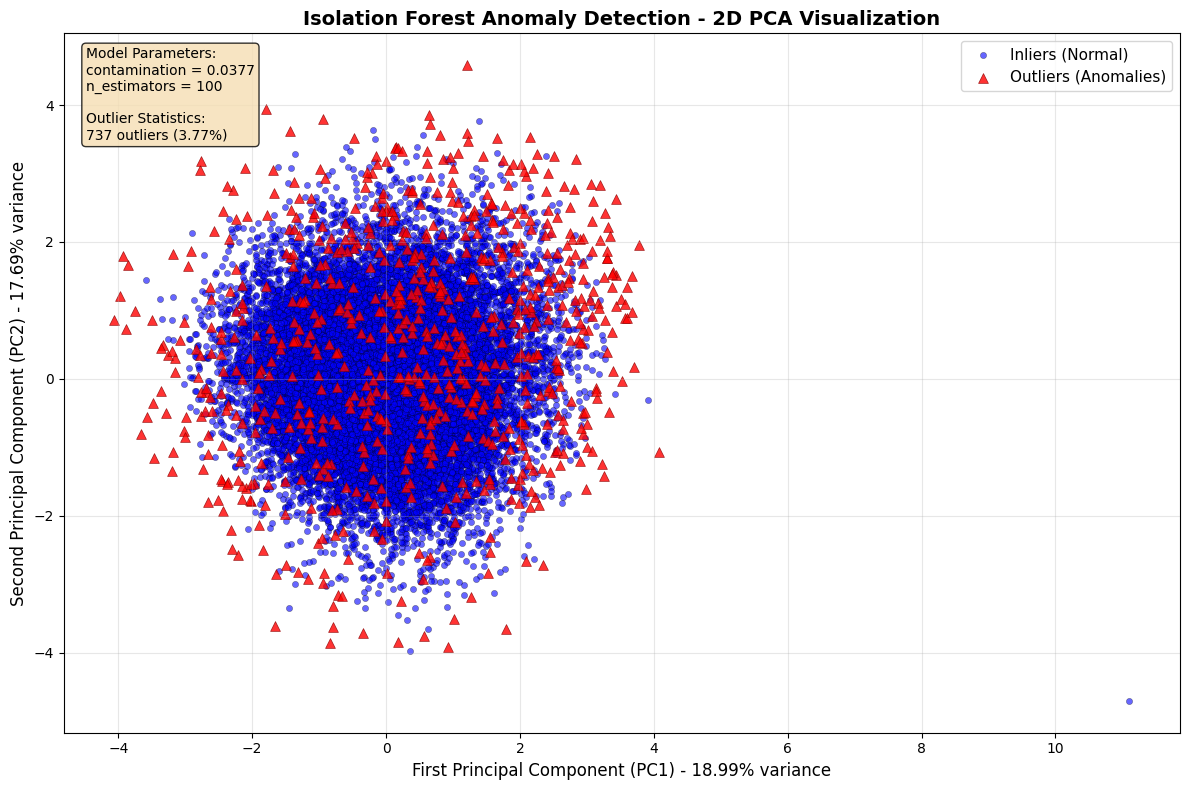

In [39]:
# Visualize Isolation Forest results (contamination=0.0377, ~3.77% outliers)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot inliers (normal points)
inlier_mask_if_2 = ~outlier_mask_if_2
plt.scatter(X_pca_if[inlier_mask_if_2, 0], X_pca_if[inlier_mask_if_2, 1], 
            c='blue', alpha=0.6, s=20, label='Inliers (Normal)', 
            edgecolors='black', linewidths=0.3)

# Plot outliers (anomalies) in a different color
plt.scatter(X_pca_if[outlier_mask_if_2, 0], X_pca_if[outlier_mask_if_2, 1], 
            c='red', alpha=0.8, s=50, label='Outliers (Anomalies)', 
            edgecolors='darkred', linewidths=0.5, marker='^')

# Add labels and title
plt.xlabel(f'First Principal Component (PC1) - {explained_variance_if[0]:.2%} variance', fontsize=12)
plt.ylabel(f'Second Principal Component (PC2) - {explained_variance_if[1]:.2%} variance', fontsize=12)
plt.title('Isolation Forest Anomaly Detection - 2D PCA Visualization', fontsize=14, fontweight='bold')

# Add text box with model parameters and outlier statistics
textstr = f'Model Parameters:\ncontamination = {iso_forest_2.contamination}\nn_estimators = {iso_forest_2.n_estimators}\n\nOutlier Statistics:\n{outlier_mask_if_2.sum()} outliers ({outlier_percentage_if_2:.2f}%)'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### Insights about Isolation Forest Results

From isolation forest we were able to pre-determine the % of outliers, so any value between 1% to 5% would have been acceptable as a contamination value. I chose 3.77% so we could compare the anomaly patterns in the graphs. If we compare the two PCAs together of OCSVM & Isolation Forest, we can see that isolation forest has less density of outliers within the middle of the inlier bunch, pointing towards this being a more accurate methodology to finding anomalies. However, "thumb in the air estimate" is not a reliable method for comparing similar graphs such as these. On top of this, the isolation forest missed a very obvious outlier in the isolation forest PCA, indicating some issues.

The methodology and the rest of comparison of models used will be covered in the report.